In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import phd_parser as pp

In [2]:
path_drifts = Path(r"C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\21_Experiments\01_raw\Box5_Spectrocsopy")
path_experiment = path_drifts / "2026-03-26_SK1002"
path_ir = path_experiment / "omnic" / "01_Reduction"

# path_ir = Path(r"..\\tests\\infrared\\omnic-test-data")

In [11]:
tos_start = pd.Timestamp("2026-03-26 14:00:00", tz="Europe/Amsterdam")

In [12]:
ir_raw = pp.infrared.IRData.from_omnic_spa(path_ir, tos_start=tos_start)

Raw tos_start from metadata: Timestamp('2026-03-26 14:00:00+0100', tz='Europe/Amsterdam')


In [13]:
ir = ir_raw.select_wavenumber_range(1000, None).smooth_moving(window_size=5)

In [14]:
ir_ = ir.average_scans(20, tos_method="first")

In [15]:
print(ir_raw.shape, ir.shape, ir_.shape)

(2975, 7468) (2975, 6223) (148, 6223)


In [16]:
ir.wavenumber

array([400012.23144531, 399964.01977457, 399915.80810383, ...,
       100135.63944703, 100087.42777629, 100039.21610555], shape=(6223,))

In [17]:
ir.energy_eV

array([0.49595196, 0.49589218, 0.49583241, ..., 0.12415237, 0.1240926 ,
       0.12403282], shape=(6223,))

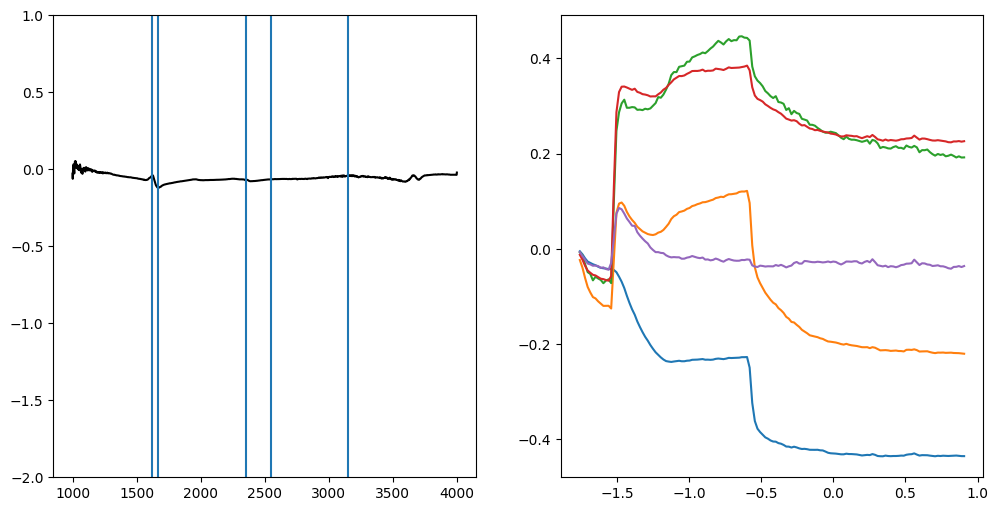

In [18]:
wavernumbers = [1620, 1670, 2358, 2550, 3150]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ax0 = axes.ravel()[0]
ax0.set_ylim(-2, 1)
ax1 = axes.ravel()[1]

ax0.plot(ir_.wavenumber_per_cm, ir_.values[10], color = "black", label="Last spectrum")


for wn in wavernumbers:
    ax0.axvline(wn)
    ax1.plot(ir_.tos / 3600, ir_.get_evolution(wavenumber_per_cm = wn))